<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 3: 모델 추가 학습**

## **미션 설명**

- 이번 단계에서는 다음과 같이 3개의 미션을 수행합니다.

### 미션 8: 전처리 파이프라인 만들기

- 새로운 학습용/검증용 데이터에 대해 매번 전처리 작업을 수행해야 합니다.
- 반복되는 전처리 작업은 비효율적인 업무 중 하나입니다.
- 이러한 문제를 해결하기 위해 다음과 같은 처리를 일괄 수행하는 파이프라인 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등

### 미션 9: 기본 모델로 예측 및 평가

- 이전 과정에서 만든 모델이 기본 모델(Base Model)입니다.
- 새로 전달 받은 평가용 데이터로 기존에 만든 모델의 성능을 평가해봅니다.

### 미션 10: 추가 학습

- 문제 상황에 맞게 가장 적절한 방법으로 모델 추가 학습을 진행합니다.
- 추가 학습 후 이전에 평가했던 새로운 평가 데이터로 다시 평가해 성능 향상을 확인합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [57]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [58]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 학습 곡선 시각화 함수 만들기

- 모델링 수행 시 학습 상황을 시각화해 확인하기 위한 함수를 만듭니다.

In [59]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

### (4) 기본 모델 및 데이터 불러오기

- 우선 이전 과정에서 저장한 모델을 불러와 base_model로 선언합니다.
    - path + 'base_model.keras' →  base_model
- **load_model()** 함수를 사용합니다.


In [60]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

- 이전 과정에서 저장한 스케일러를 불러와 scaler 변수에 저장합니다.
    - path + 'scaler.pkl' →  scaler
- **joblib.load()** 함수를 사용합니다.

In [61]:
# 스케일러 불러오기
scaler = joblib.load(path + 'scaler.pkl')

- 이전 과정에서 저장한 파일을 읽어와 new_test, new_train 데이터프레임을 만듭니다.
    - path + 'new_test.csv' → new_test
    - path + 'new_train.csv' → new_train

In [62]:
# 파일 불러오기
new_test = pd.read_csv(path + 'new_test.csv')
new_train = pd.read_csv(path + 'new_train.csv')

In [63]:
new_test.head()

new_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         350 non-null    int64  
 1   ID                                 350 non-null    int64  
 2   Gender                             350 non-null    object 
 3   Customer Type                      350 non-null    object 
 4   Age                                340 non-null    float64
 5   Type of Travel                     350 non-null    object 
 6   Class                              350 non-null    object 
 7   Flight Distance                    350 non-null    int64  
 8   Inflight wifi service              335 non-null    float64
 9   Departure/Arrival time convenient  350 non-null    int64  
 10  Ease of Online booking             350 non-null    int64  
 11  Gate location                      350 non-null    int64  

In [64]:
new_test.isnull().sum()

,0
Unnamed: 0,0
ID,0
Gender,0
Customer Type,0
Age,10
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,15
Departure/Arrival time convenient,0


In [65]:
(new_test.isnull().sum() / len(new_test)).sort_values(ascending=False)

,0
Inflight wifi service,0.042857
Age,0.028571
Food and drink,0.022857
Seat comfort,0.011429
Unnamed: 0,0.000000
Customer Type,0.000000
Type of Travel,0.000000
Gender,0.000000
ID,0.000000
Flight Distance,0.000000


## **2. 미션 8: 전처리 파이프라인 만들기**

- 다음 과정을 일괄 처리한 후 x, y를 반환하는 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등
- 함수 이름은 **build_model_input** 로 지정합니다.
- 다음과 같이 사용할 수 있어야 합니다.
    - 예1) x_val, y_val = build_model_input(new_test)
    - 예2) x_trian, y_train = build_model_input(new_train)


In [66]:
# import pandas as pd

# # 함수 만들기
# def build_model_input(data):
#     # 원본 훼손 방지
#     df = data.copy()

#     # 1. 결측치 처리
#     num_cols = df.select_dtypes(include=['number']).columns
#     cat_cols = df.select_dtypes(include=['object', 'category']).columns

#     for col in num_cols:
#         df[col] = df[col].fillna(df[col].median())

#     for col in cat_cols:
#         df[col] = df[col].fillna(df[col].mode()[0])

#     # 2. 값 변경
#     target = 'Satisfaction'

#     df[target] = df[target].map({'Satisfied' : 1, 'Neutral or Dissatisfied' : 0})

#     # if target in df.columns:
#     #     df[target] = df[target].map({'Satisfied' : 1, 'Neutral or Dissatisfied' : 0})
#     #     # 혹시 모를 타겟 결측치 0으로 채우기
#     #     df[target] = df[target].fillna(0)

#     # 3. 변수 제거
#     df.drop(['Unnamed: 0', 'ID'], axis=1, inplace=True, errors='ignore')

#     # 4. 라벨 인코딩 (에러 메시지에 'Missing'이라고 뜬 4개 변수 대상)
#     # 문자열 변수 리스트로 선언
#     cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

#     # 라벨 인코딩
#     for col in cat_cols:
#         encoder = LabelEncoder()
#         df[col] = encoder.fit_transform(df[col])

#     # 5. 가변수화 (나머지 설문 항목 14개 변수 대상)
#     # 에러 메시지에 'Baggage handling_1' 등이 Missing에 없으므로 얘네는 가변수화 대상입니다.
#     # 설문 범주 정의
#     categories = [0, 1, 2, 3, 4, 5]

#     # 가변수화 대상 변수
#     dumm_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location',
#                 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
#                 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

#     # Category 형 변수로 변환
#     for col in dumm_cols:
#         df[col] = pd.Categorical(df[col], categories=categories)

#     # 가변수화
#     # 전체 데이터에서 먼저 하면: 한 번에 모든 범주형 변수를 처리한 뒤, 나중에 Target(y)만 쏙 뽑아내고 나머지를 x로 정의하면 되므로 코드가 훨씬 간결해짐
#     df = pd.get_dummies(df, columns = dumm_cols, drop_first=True, dtype=int)
#     # 6. x, y 분리

#     x = df.drop(target, axis=1)
#     y = df.loc[:,target]

#     # if target in df.columns:
#     #     x = df.drop(target, axis=1)
#     #     y = df.loc[:,target]
#     # else:
#     #     x = df.copy()
#     #     y = None

#     # # [가장 중요한 치트키]
#     # # x의 컬럼을 Train(스케일러)과 똑같이 줄 세우고, 없는 열은 0으로 채움
#     # x = x.reindex(columns=scaler.feature_names_in_, fill_value=0)

#     # 7. 스케일링
#     # Train에서 fit 해둔 scaler로 transform만 수행
#     x_scaled = scaler.transform(x)
#     x = pd.DataFrame(x_scaled, columns=x.columns)

#     # 반환
#     return x, y


def build_model_input(data):
    data = data.copy()  # 추가!

    # 1. 결측치 처리 (Satisfaction 제외)
    num_cols = data.select_dtypes(include='number').columns
    cat_cols = data.select_dtypes(include=['object', 'category']).columns
    cat_cols = cat_cols[cat_cols != 'Satisfaction']
    data[num_cols] = data[num_cols].fillna(data[num_cols].median())
    data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().iloc[0])

    # 2. 값 변경
    data['Satisfaction'] = data['Satisfaction'].map({'Satisfied': 1, 'Neutral or Dissatisfied': 0})

    # 3. 변수 제거
    data = data.drop(columns=['Unnamed: 0', 'ID'], errors='ignore')

    # 4. 라벨 인코딩
    cat_cols = data.select_dtypes(include='object').columns
    for col in cat_cols:
        encoder = LabelEncoder()
        data[col] = encoder.fit_transform(data[col])

    # 5. 가변수화
    dummy_cols = ['Inflight wifi service', 'Departure/Arrival time convenient',
                  'Ease of Online booking', 'Gate location', 'Food and drink',
                  'Online boarding', 'Seat comfort', 'Inflight entertainment',
                  'On-board service', 'Leg room service', 'Baggage handling',
                  'Checkin service', 'Inflight service', 'Cleanliness']
    for col in dummy_cols:
        data[col] = pd.Categorical(data[col], categories=[0, 1, 2, 3, 4, 5])
    data = pd.get_dummies(data, columns=dummy_cols)

    # 6. x, y 분리
    x = data.drop(columns='Satisfaction')
    y = data.loc[:, 'Satisfaction']

    # 7. 스케일링
    x = scaler.transform(x)

    return x, y

- 점검: 다음 구문이 잘 수행되어 x_val, y_val이 분리되어야 합니다.


In [67]:
# x_val, y_val 나누기
# x_train, y_train = build_model_input(new_train)
x_val, y_val = build_model_input(new_test)

# 확인

# print(x_train.shape)
# print(y_train.shape)

print(x_val.shape)
print(y_val.shape)

(350, 92)
(350,)


## **3. 미션 9: 기본 모델로 예측 및 평가**

### (1) 데이터 전처리

- new_test 데이터프레임을 x_val, y_val로 분리합니다.

In [68]:
x_val, y_val = build_model_input(new_test)

### (2) 예측 및 평가

- 새로운 데이터에 대한 예측과 평가를 수행합니다.

In [69]:
# (2) 예측 및 평가
y_pred = base_model.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0) # 이진 분류일 경우

print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
[[156  35]
 [  4 155]]
              precision    recall  f1-score   support

           0       0.97      0.82      0.89       191
           1       0.82      0.97      0.89       159

    accuracy                           0.89       350
   macro avg       0.90      0.90      0.89       350
weighted avg       0.90      0.89      0.89       350



## **4. 미션 10: 모델 추가 학습**

### (1) 학습용 데이터 준비

- new_train 데이터프레임을 x_train, y_train으로 분리합니다.

In [70]:
x_train, y_train = build_model_input(new_train)

print(x_train.shape, y_train.shape)

(850, 92) (850,)


### (2) 방법 1: 모델 초기화

- 이전에 만들었던 성능이 좋았던 모델과 같은 모델을 만들어 학습 후 성능을 확인합니다.

In [71]:
# 1. 모델 초기화 및 정의
clear_session()

n_features = x_train.shape[1]

dense = [64, 32]
dropout = 0.2

model1 = Sequential([
    Input(shape=(n_features, )),

    Dense(dense[0], activation='relu'),
    Dropout(dropout),
    Dense(dense[1], activation='relu'),
    Dropout(dropout),
    Dense(1, activation='sigmoid')
])


- 학습 방법을 설정하고 학습을 수행합니다.

In [72]:
# 2. 컴파일 및 학습
learning_rate=0.001
patience = 10
epochs = 100
batch_size=32
validation_split=0.2

model1.compile(optimizer=Adam(learning_rate=learning_rate),
               loss='binary_crossentropy',
               metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss',
                   patience=patience,
                   restore_best_weights=True)

history1 = model1.fit(x_train, y_train,
                      epochs=epochs,
                      batch_size=batch_size,
                      validation_split=validation_split,
                      callbacks=[es],
                      verbose=0)

- 학습 곡선을 확인합니다.

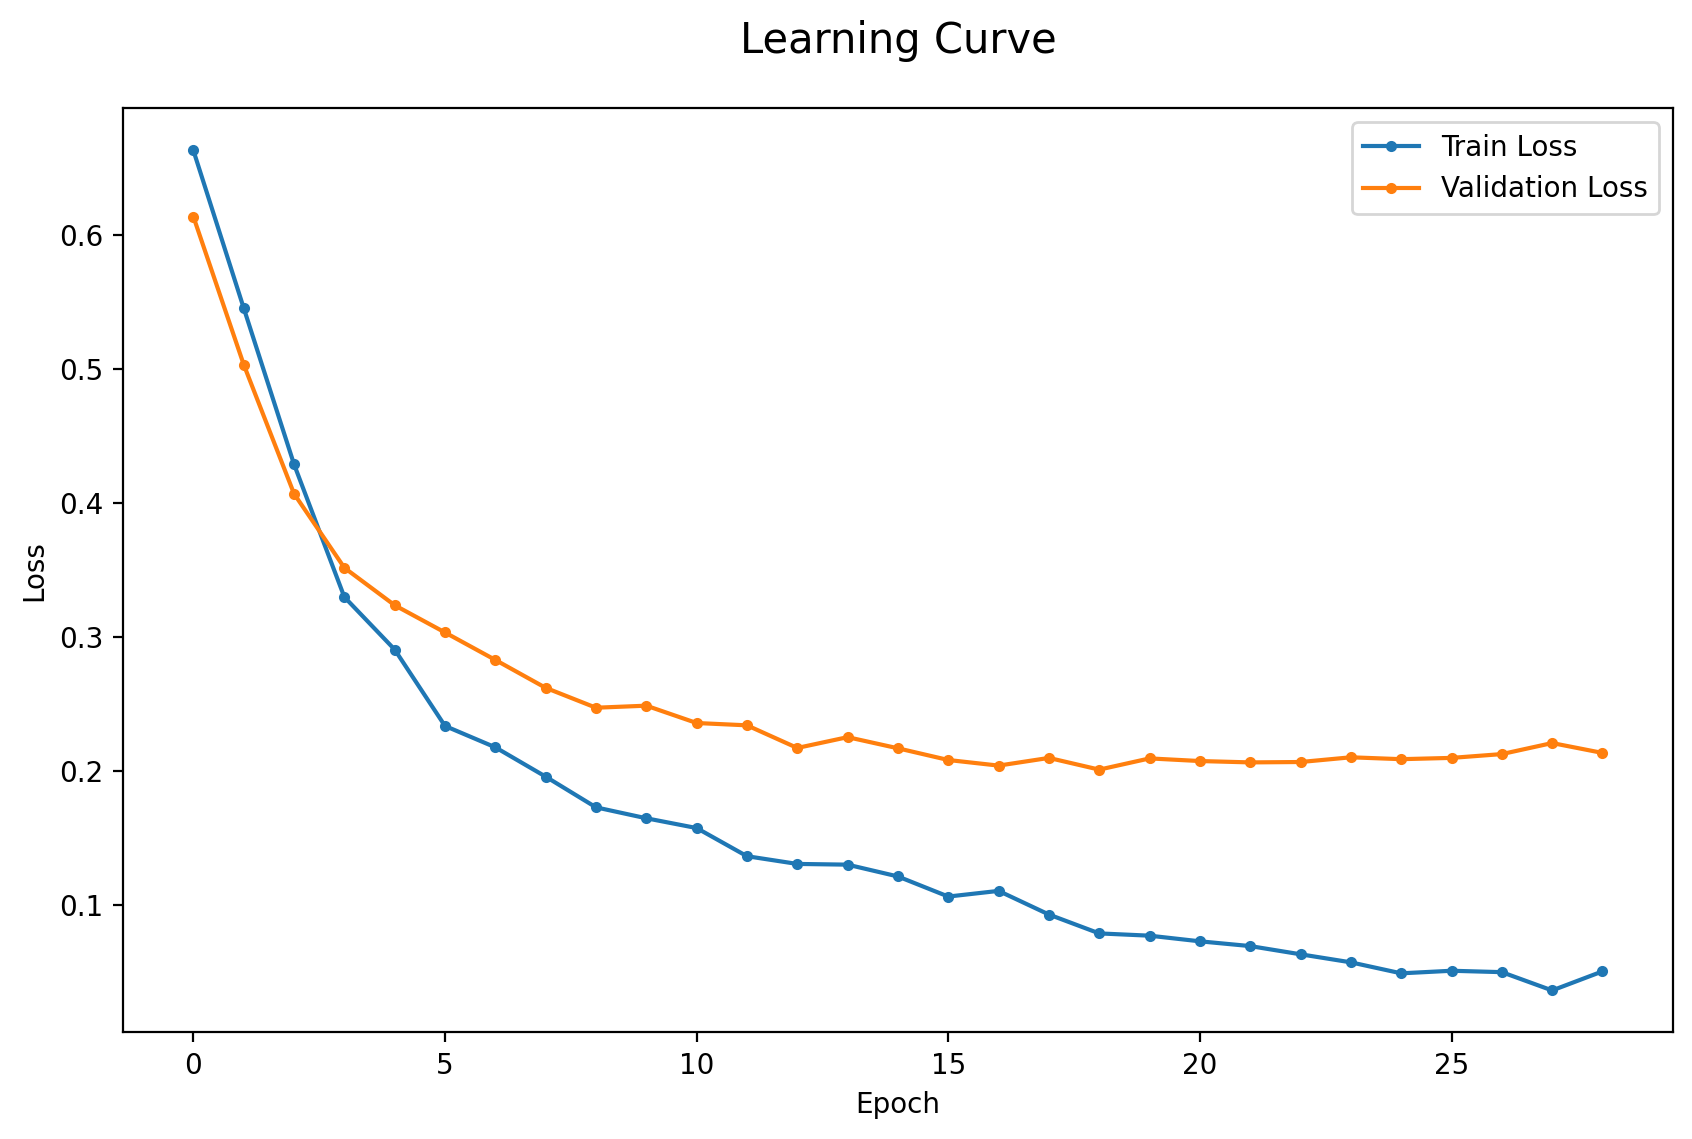

In [73]:
# 3. 시각화 (함수 사용!)
dl_history_plot(history1.history)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [74]:
# 1. 예측 (확률 값으로 출력됨)
y_pred_base = base_model.predict(x_val)

# 2. 0.5를 기준으로 0과 1로 변환
y_pred_base = np.where(y_pred_base > 0.5, 1, 0)

# 3. 평가 결과 출력
print("===== Base Model Evaluation =====")
print(confusion_matrix(y_val, y_pred_base))
print(classification_report(y_val, y_pred_base))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
===== Base Model Evaluation =====
[[156  35]
 [  4 155]]
              precision    recall  f1-score   support

           0       0.97      0.82      0.89       191
           1       0.82      0.97      0.89       159

    accuracy                           0.89       350
   macro avg       0.90      0.90      0.89       350
weighted avg       0.90      0.89      0.89       350



### (3) 방법 2: 추가 학습

- 기본 모델을 기반으로 모델을 선언하고 추가 학습 후 성능을 확인합니다.

In [75]:
# base_model을 그대로 사용 (컴파일 설정 확인 필요)
base_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy') # 보통 낮은 LR 권장


- 학습 방법을 설정하고 학습을 수행합니다.

In [76]:
history2 = base_model.fit(x_train, y_train, epochs=30, validation_split=0.2, verbose=0)

- 학습 곡선을 확인합니다.

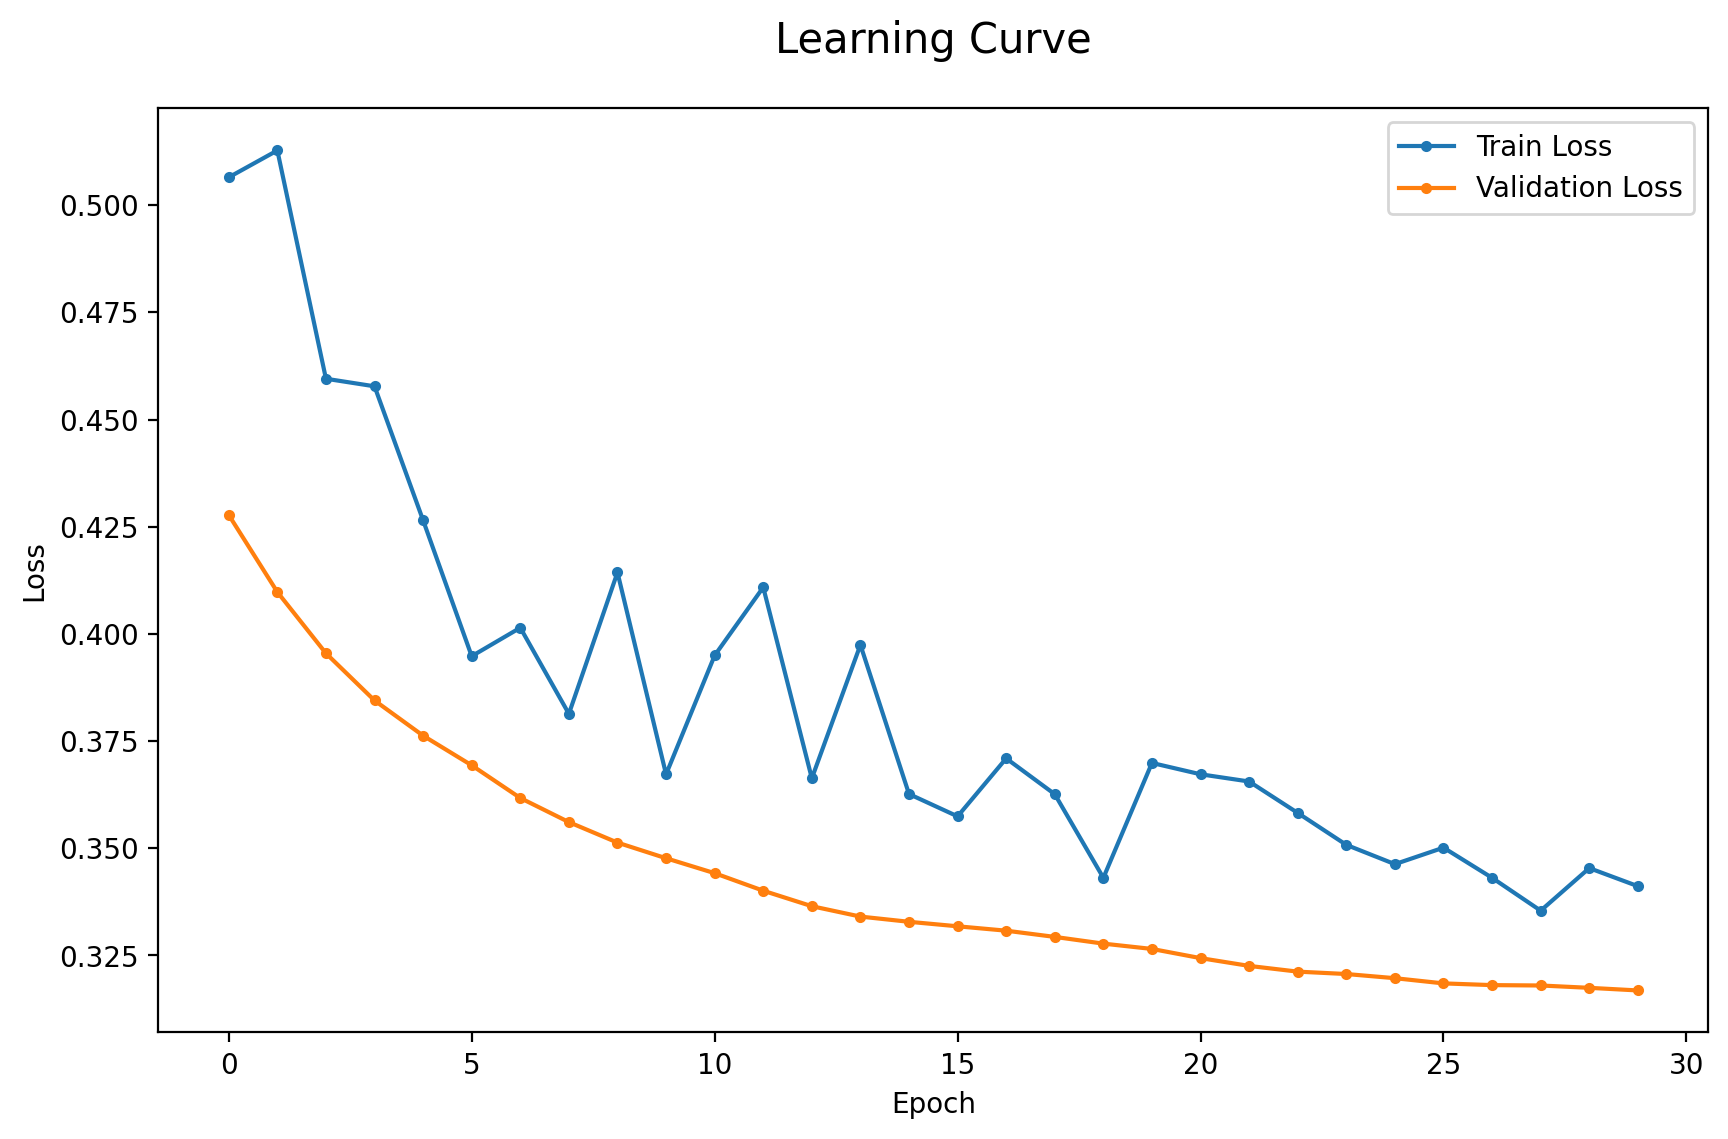

In [77]:
dl_history_plot(history2.history)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [78]:
# 1. 예측
y_pred2 = model1.predict(x_val)
y_pred2 = np.where(y_pred2 > 0.5, 1, 0)

# 2. 평가
print("===== Method 2 (Continued-training) Evaluation =====")
print(confusion_matrix(y_val, y_pred2))
print(classification_report(y_val, y_pred2))


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
===== Method 2 (Continued-training) Evaluation =====
[[178  13]
 [ 14 145]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       191
           1       0.92      0.91      0.91       159

    accuracy                           0.92       350
   macro avg       0.92      0.92      0.92       350
weighted avg       0.92      0.92      0.92       350



### (4) 방법 3: 미세조정

- 기본 모델의 앞쪽 레이어 일부의 학습 기능을 비활성화합니다.
- 기본 모델을 기반으로 레이어를 추가한 모델을 선언합니다.
- 추가 학습을 진행한 뒤 성능을 확인합니다.

In [79]:
# 모델 불러오기
model3 = load_model(path + 'base_model.keras')

model3.summary()

# 마지막 레이어 제거
model3.pop()

model3.add(Dense(4, activation='relu', name='new_dense_4'))
model3.add(Dropout(0.5, name='new_dropout'))
model3.add(Dense(1, activation='sigmoid', name='new_dense_last'))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,117 (102.02 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,412 (68.02 KB)

- 학습 방법을 설정하고 학습을 수행합니다.

In [80]:
model3.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy')
history3 = model3.fit(x_train, y_train, epochs=30, validation_split=0.2, verbose=0)


- 학습 곡선을 확인합니다.

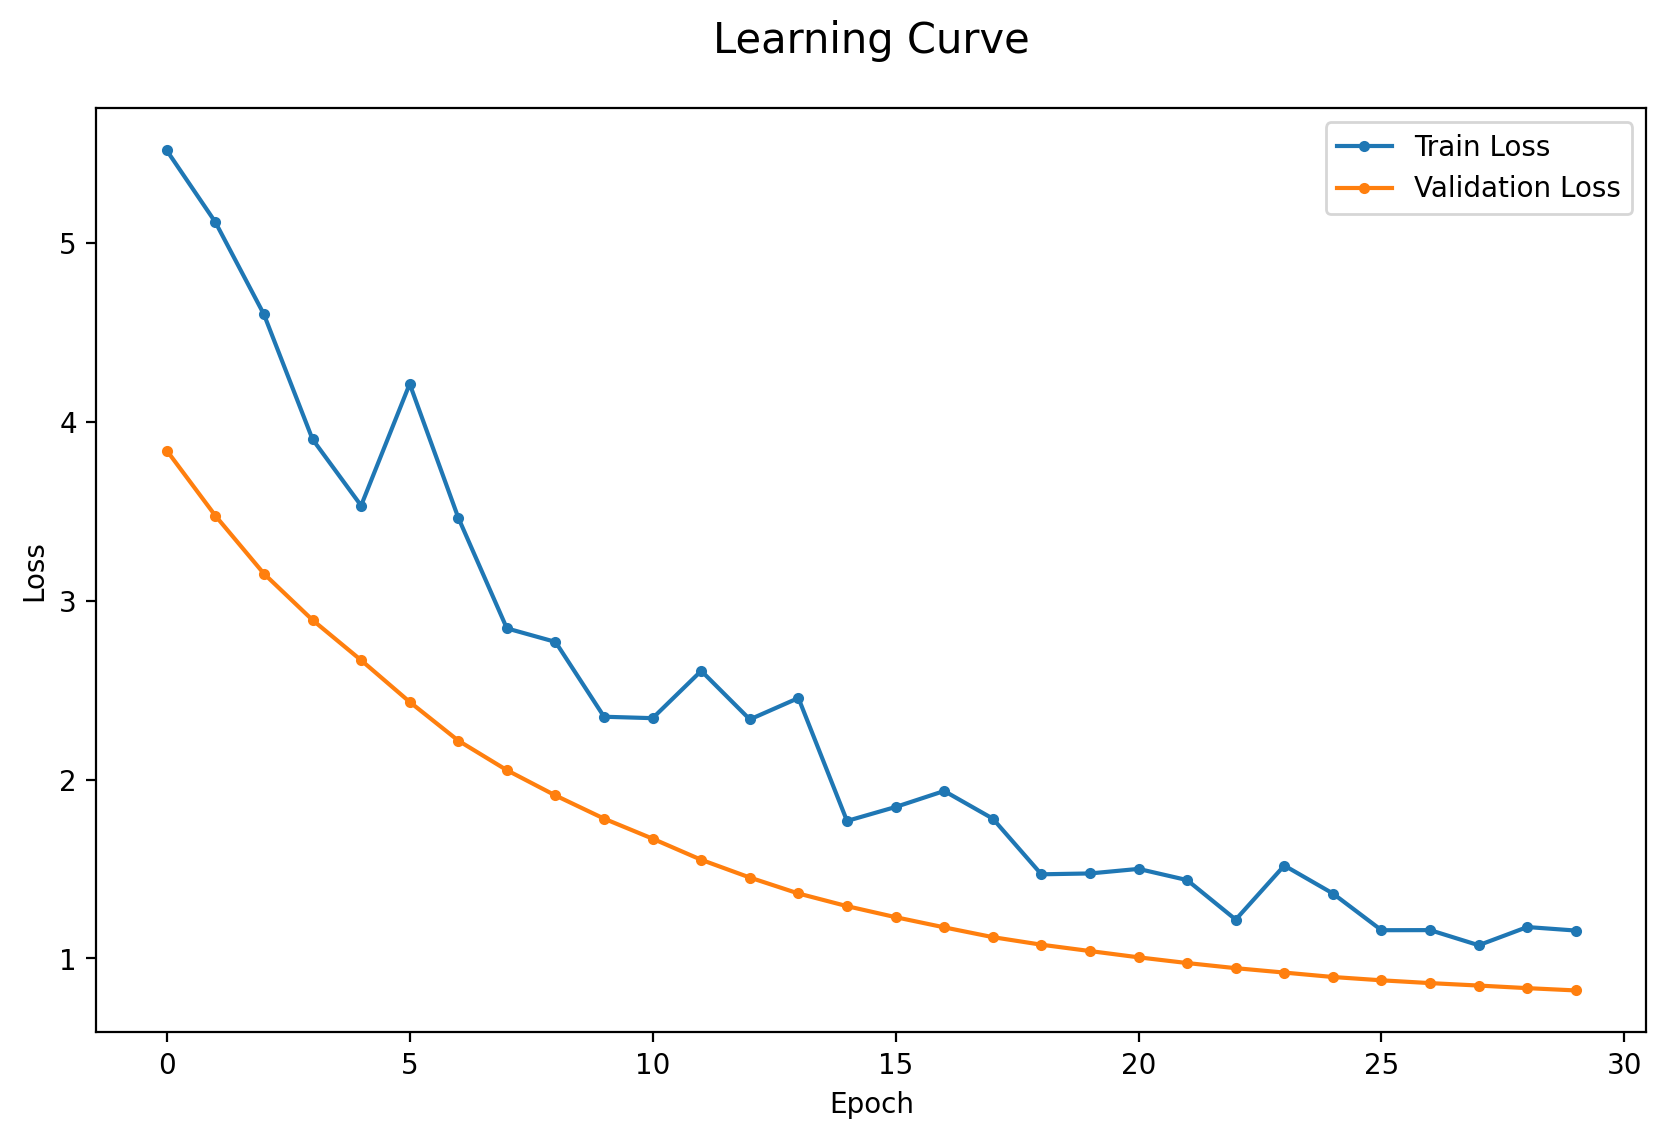

In [81]:
dl_history_plot(history3.history)


- 검증 데이터로 예측 및 평가를 수행합니다.

In [82]:
# 1. 예측
y_pred3 = model3.predict(x_val)
y_pred3 = np.where(y_pred3 > 0.5, 1, 0)

# 2. 평가
print("===== Method 3 (Fine-tuning) Evaluation =====")
print(confusion_matrix(y_val, y_pred3))
print(classification_report(y_val, y_pred3))


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
===== Method 3 (Fine-tuning) Evaluation =====
[[  2 189]
 [ 65  94]]
              precision    recall  f1-score   support

           0       0.03      0.01      0.02       191
           1       0.33      0.59      0.43       159

    accuracy                           0.27       350
   macro avg       0.18      0.30      0.22       350
weighted avg       0.17      0.27      0.20       350



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_dense_4 (Dense)             │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_dropout (Dropout)           │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_dense_last (Dense)          │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,213 (102.40 KB)

 Trainable params: 8,737 (34.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,476 (68.27 KB)

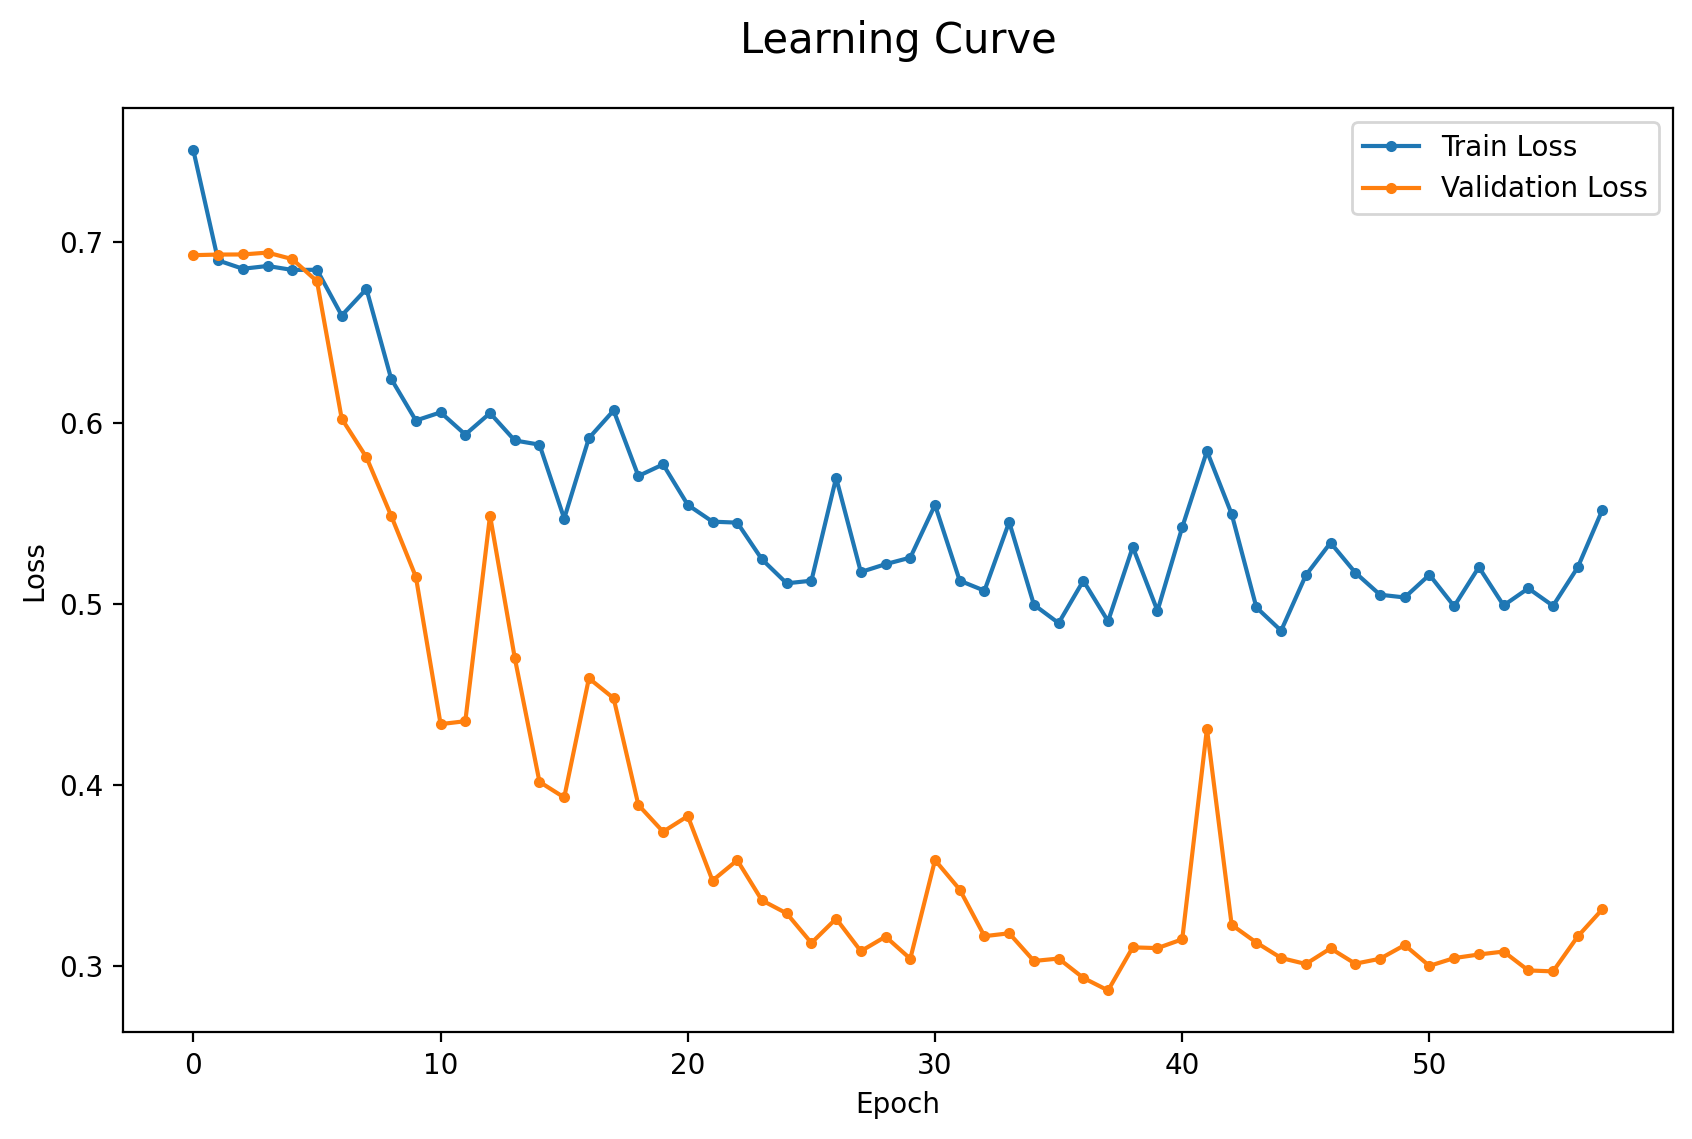

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       191
           1       0.95      0.86      0.90       159

    accuracy                           0.91       350
   macro avg       0.92      0.91      0.91       350
weighted avg       0.92      0.91      0.91       350



In [83]:


fine_model = model3
fine_model.summary()

# 셀 2: 학습 방법 설정 및 학습
fine_model.compile(optimizer=Adam(learning_rate=0.007),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
hist = fine_model.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=0, callbacks=[es]).history

# 셀 3: 학습 곡선
dl_history_plot(hist)

# 셀 4: 예측 및 평가
y_pred = fine_model.predict(x_val)
y_pred = np.where(y_pred >= 0.5, 1, 0)
print(classification_report(y_val, y_pred))

In [84]:
def finetune_pipeline(path, model_name, x_train, y_train, x_val, y_val,
                      freeze_layers=0,     # 동결할 앞쪽 레이어 개수
                      new_nodes=[4],       # 새로 추가할 층의 노드 리스트
                      dropout=0.5,         # 드롭아웃 비율
                      lr=0.007,            # 학습률 (Learning Rate)
                      patience=20,         # 조기 종료 대기 횟수
                      min_delta=0.001,     # 개선으로 인정할 최소 변화량
                      epochs=100,          # 최대 에포크
                      batch_size=32):      # 배치 사이즈

    # 1. 초기화 및 모델 로드
    clear_session()
    base_model = load_model(path + model_name)

    # 2. 마지막 레이어(출력층) 제거
    base_model.pop()

    # 3. 레이어 동결 설정 (선택 사항)
    # 특정 층까지는 학습되지 않도록 가중치를 고정함
    if freeze_layers > 0:
        for layer in base_model.layers[:freeze_layers]:
            layer.trainable = False

    # 4. 새로운 레이어 추가 (Fine-tuning 구조 설계)
    # 기존 base_model 위에 새로운 층을 쌓음
    model = Sequential([base_model])

    for n in new_nodes:
        model.add(Dense(n, activation='relu'))
        if dropout > 0:
            model.add(Dropout(dropout))

    # 최종 출력층 추가 (만족/불만족 분류)
    model.add(Dense(1, activation='sigmoid'))

    # 5. 컴파일
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    # 6. 조기 종료 (EarlyStopping)
    es = EarlyStopping(monitor='val_loss',
                       patience=patience,
                       min_delta=min_delta,
                       restore_best_weights=True,
                       verbose=1)

    # 7. 학습 (fit)
    print(f"\n[Fine-tuning] Freeze: {freeze_layers} | Nodes: {new_nodes} | LR: {lr}")
    hist = model.fit(x_train, y_train,
                     epochs=epochs,
                     batch_size=batch_size,
                     validation_split=0.2,
                     callbacks=[es],
                     verbose=0) # 1로 설정하면 학습 과정을 상세히 볼 수 있음

    # 8. 학습 곡선 시각화 (기존 정의 함수 사용)
    dl_history_plot(hist.history)

    # 9. 예측 및 평가
    y_pred = model.predict(x_val)
    y_pred_class = np.where(y_pred >= 0.5, 1, 0)

    print("-" * 50)
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_class))
    print("\nClassification Report:\n", classification_report(y_val, y_pred_class))
    print("-" * 50)

    return model, hist


[Fine-tuning] Freeze: 0 | Nodes: [64, 32, 16, 8, 4] | LR: 0.001
Epoch 62: early stopping
Restoring model weights from the end of the best epoch: 52.


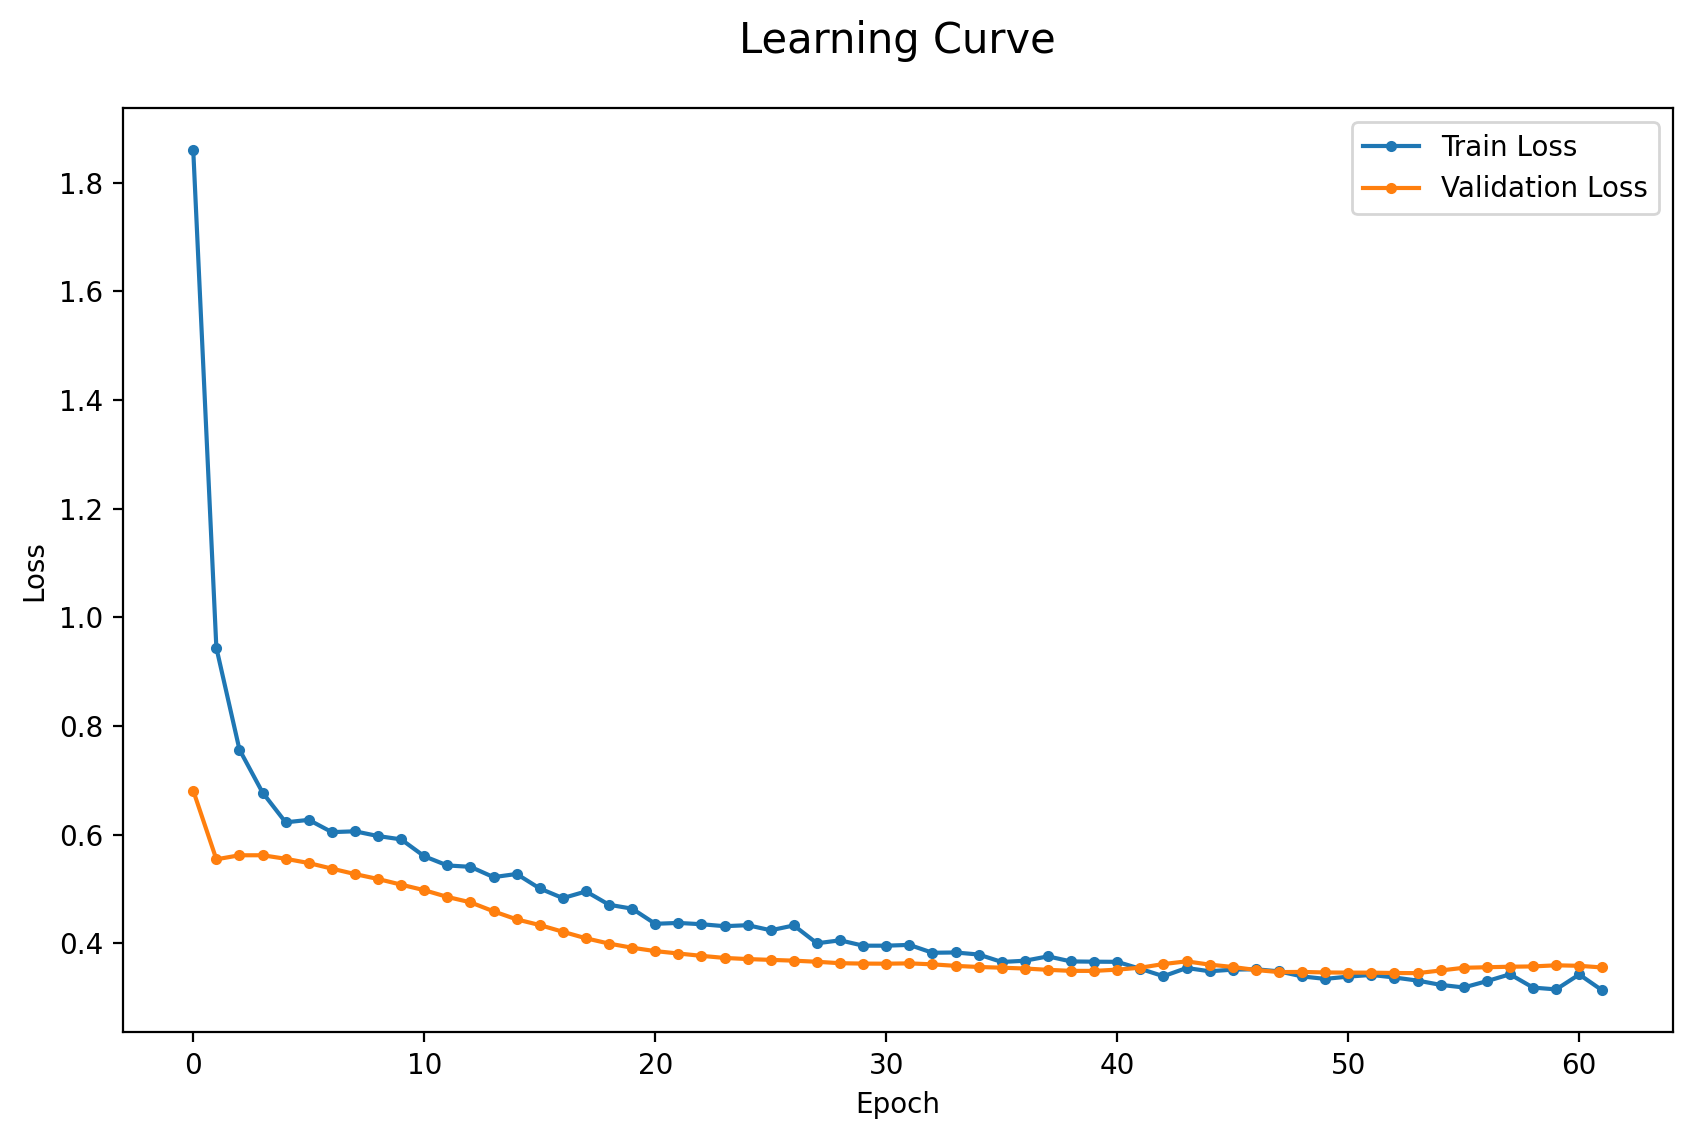

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
--------------------------------------------------
Confusion Matrix:
 [[181  10]
 [ 12 147]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.94       191
           1       0.94      0.92      0.93       159

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350

--------------------------------------------------


In [85]:
model_ft1, hist_ft1 = finetune_pipeline(
    path, 'base_model.keras', x_train, y_train, x_val, y_val,
    new_nodes=[64,32,16,8,4],
    dropout=0.1,
    lr=0.001,
    patience=10,
    min_delta=0.001,
    epochs=100,
    batch_size=128
)


[Fine-tuning] Freeze: 0 | Nodes: [64, 32, 8, 4] | LR: 0.001
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 33.


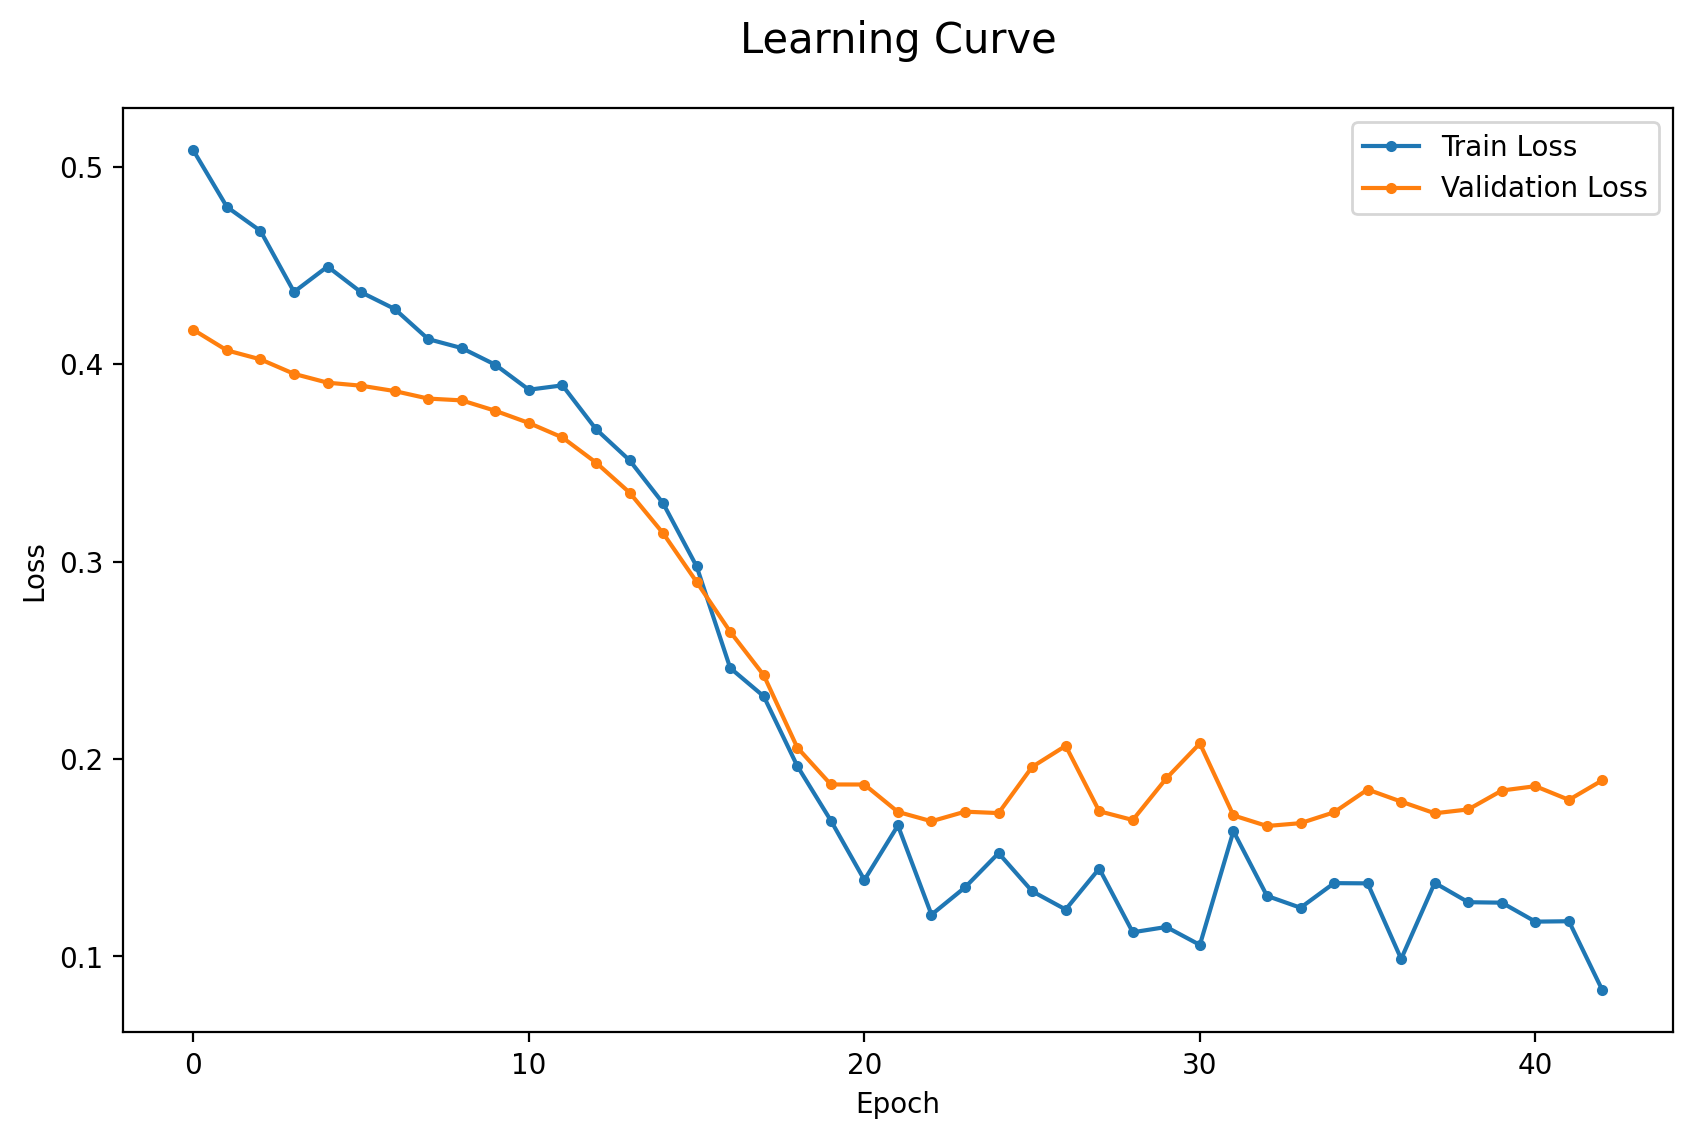

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
--------------------------------------------------
Confusion Matrix:
 [[181  10]
 [ 12 147]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.94       191
           1       0.94      0.92      0.93       159

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350

--------------------------------------------------


In [86]:
model_ft2, hist_ft2 = finetune_pipeline(
    path, 'base_model.keras', x_train, y_train, x_val, y_val,
    new_nodes=[64,32,8,4],
    dropout=0.1,
    lr=0.001,
    patience=10,
    min_delta=0.001,
    epochs=200,
    batch_size=64
)


[Fine-tuning] Freeze: 0 | Nodes: [64, 32, 8, 4] | LR: 0.001
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 16.


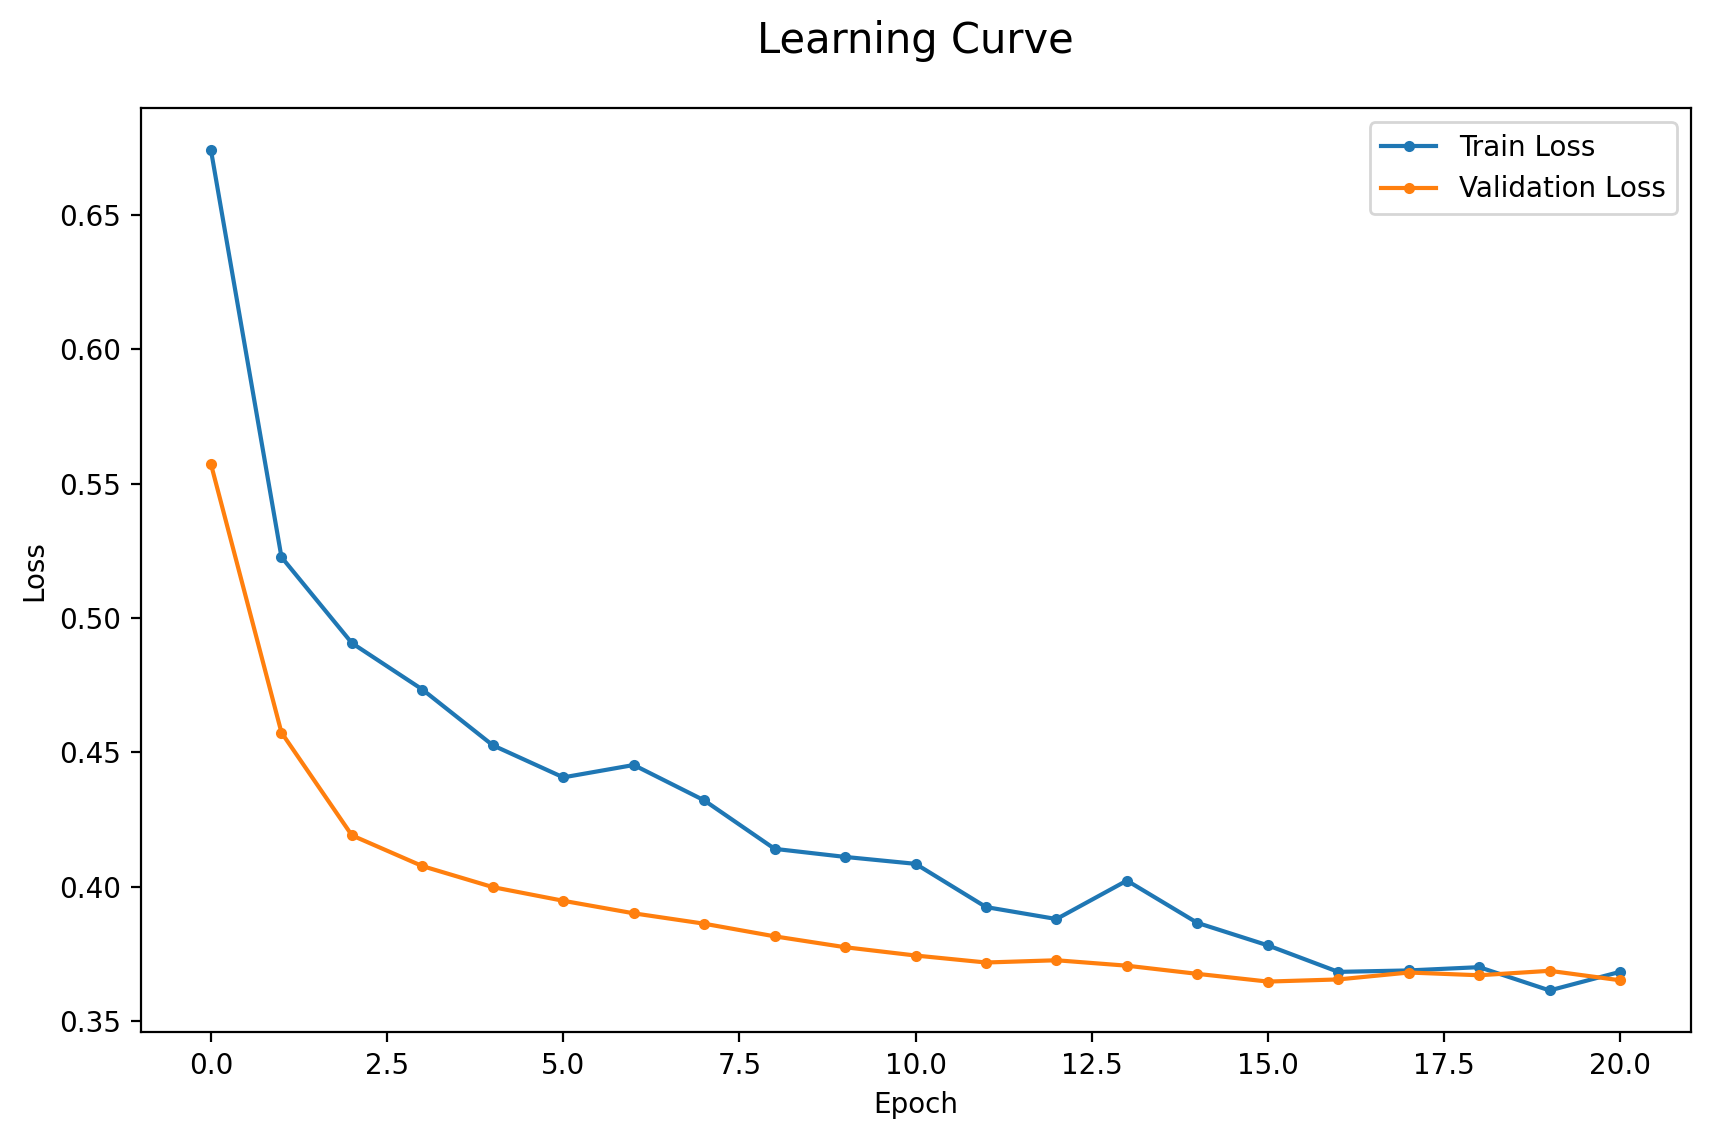

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
--------------------------------------------------
Confusion Matrix:
 [[183   8]
 [ 13 146]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95       191
           1       0.95      0.92      0.93       159

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350

--------------------------------------------------


In [87]:
model_ft3, hist_ft3 = finetune_pipeline(
    path, 'base_model.keras', x_train, y_train, x_val, y_val,
    new_nodes=[64,32,8,4],
    dropout=0.1,
    lr=0.001,
    patience=5,
    min_delta=0.001,
    epochs=300,
    batch_size=64
)


[Fine-tuning] Freeze: 0 | Nodes: [64, 16, 8, 4] | LR: 0.001
Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 14.


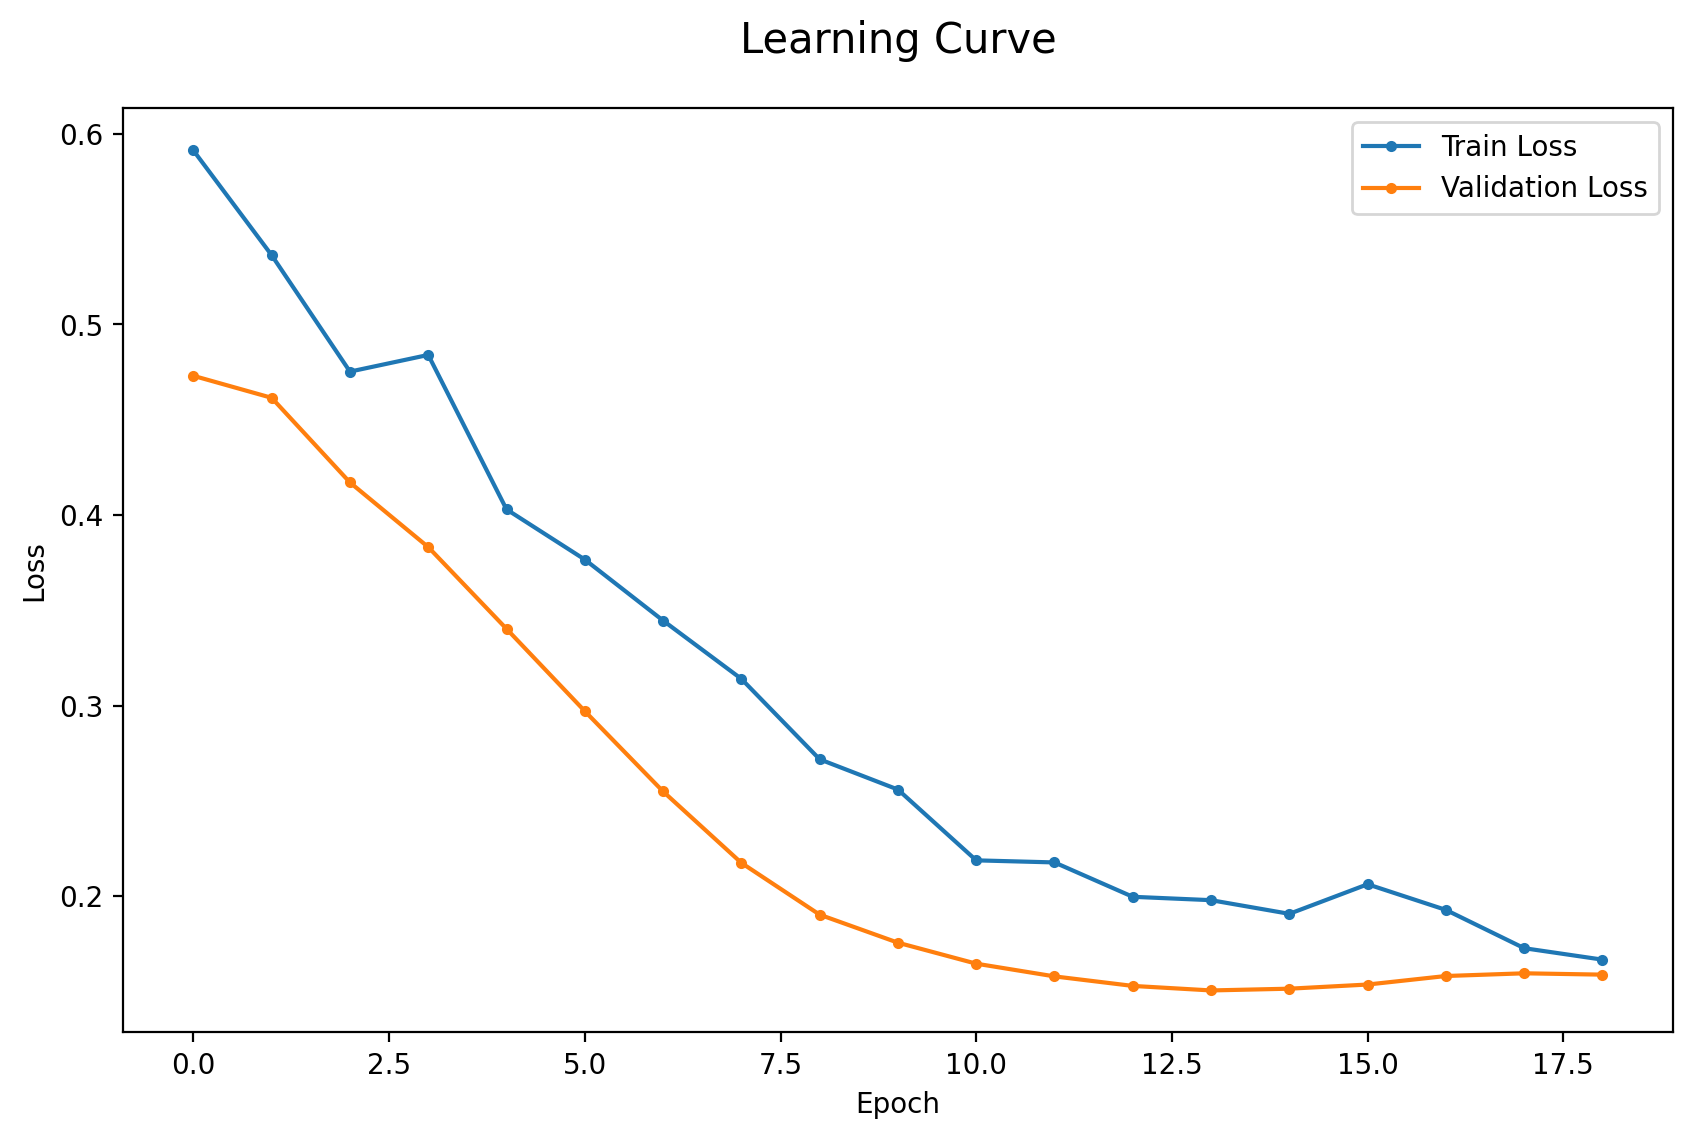

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
--------------------------------------------------
Confusion Matrix:
 [[182   9]
 [ 10 149]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95       191
           1       0.94      0.94      0.94       159

    accuracy                           0.95       350
   macro avg       0.95      0.94      0.95       350
weighted avg       0.95      0.95      0.95       350

--------------------------------------------------


In [88]:
model_ft4, hist_ft4 = finetune_pipeline(
    path, 'base_model.keras', x_train, y_train, x_val, y_val,
    new_nodes=[64,16,8,4],
    dropout=0.1,
    lr=0.001,
    patience=5,
    min_delta=0.001,
    epochs=200,
    batch_size=64
)